# STOR Math 235 Lab 5: Eigen-values of symmetric matrices; basics of  optimization.

The goal of this Lab is to wrap up the last portion of Matrix Algebra namely eigen-values and eigen-vectors and their use in classifying types of symmetric matrices and then proceeding to basics of calculus.





In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la

# I. Eigen-values and types of matrices

For this portion of the Lab you will need to

a) Create matrices in Python (see the very bottom of Lab 1 for example).

b) Find the Eigen-values of a matrix.

## Problem 1

**Problem 1.1 [2 points]**:  

Consider the matrix

$$
B = \begin{bmatrix}
4 & -1 & 0 \\
-1 & 5 & -2 \\
0 & -2 & 3
\end{bmatrix}
$$

Make an np.array for the matrix B.

In [2]:
B = np.array([[4, -1, 0],
              [-1, 5, -2],
              [0, -2, 3]])
B

array([[ 4, -1,  0],
       [-1,  5, -2],
       [ 0, -2,  3]])

In [3]:
def plot_eigenvalues(matrix):
    # Check if the matrix is symmetric
    if not np.allclose(matrix, matrix.T):
        raise ValueError("The matrix is not symmetric")

    # Compute the eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)

    # Plot the eigenvalues
    plt.plot(eigenvalues, 'o')
    plt.title("Eigenvalues of the matrix")
    plt.xlabel("Index")
    plt.ylabel("Eigenvalue")
    plt.show()

**Problem 1.2 [2 points]:** Use the above function on your matrix B to find and plot the eigenvalues of B.

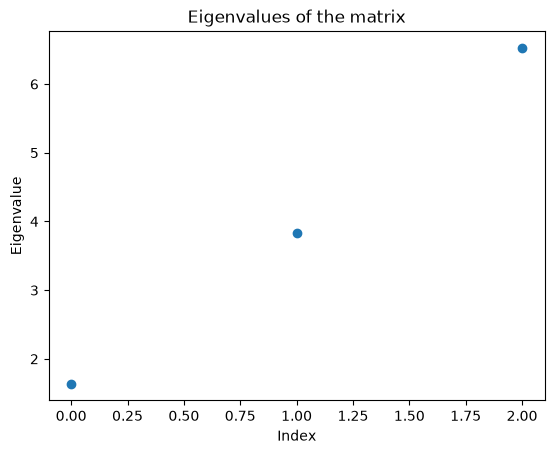

In [4]:
plt.figure()
plot_eigenvalues(B)

**Problem 1.3 [2 points]** Print the eigenvalues of B sorted.  I've gotten you started.

In [5]:
eigenvalues = np.linalg.eigvalsh(B)
print("Sorted eigenvalues of B:", eigenvalues)

Sorted eigenvalues of B: [1.63853123 3.83255081 6.52891796]


**Problem 1.4 [4 points]**: Look at the last few slides of module 2 where different types of symmetric matrices were classified as positive definite, positive semi-definite, negative definite etc. **What kind of matrix is B?** Type your answer (you can edit this text block)

B is **positive definite** because it is symmetric and all its eigenvalues are strictly positive (approximately 1.638531, 3.832551, and 6.528918).

### Problem 2 [10 points]

Repeat all of the above steps (plot eigen values, find the eigen-values and claissify the type of matrix) for the matrix

$$
C = \begin{bmatrix}
-6 & -1 & 0 \\
-1 & -5 & -2 \\
0 & -2 & -7
\end{bmatrix}
$$

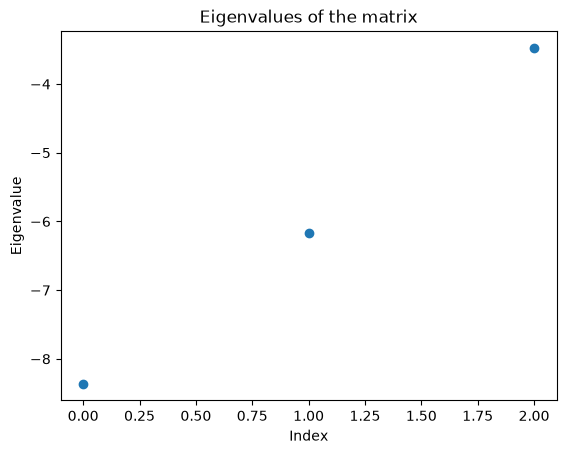

Sorted eigenvalues of C: [-8.36146877 -6.16744919 -3.47108204]


In [6]:
C = np.array([[-6, -1, 0],
              [-1, -5, -2],
              [0, -2, -7]])
plt.figure()
plot_eigenvalues(C)
print("Sorted eigenvalues of C:", np.linalg.eigvalsh(C))

C is **negative definite** because it is symmetric and all its eigenvalues are strictly negative (approximately -8.361469, -6.167449, and -3.471082).

### Problem 3 [10 points]

Repeat all of the above steps (plot eigen values, find the eigen-values and claissify the type of matrix) for the matrix $A$ given below.

In [7]:
A = np.array([
  [0, 1, 1, 0, 0, 0, 0, 0, 1, 1],
  [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
  [1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
  [0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
  [0, 0, 0, 1, 1, 0, 1, 1, 0, 0],
  [0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
  [0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
  [1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
  [1, 0, 0, 0, 0, 0, 0, 0, 1, 0]])

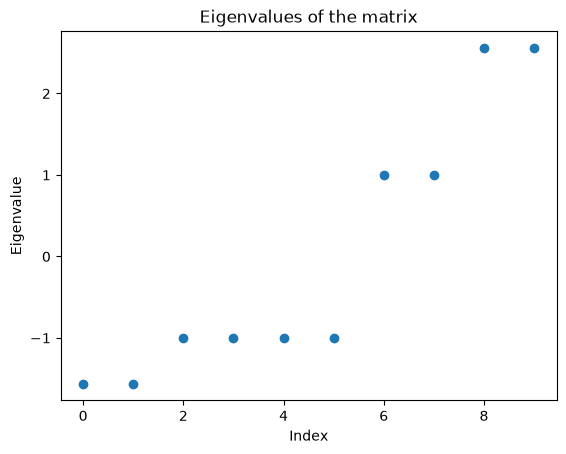

Sorted eigenvalues of A: [-1.56155281 -1.56155281 -1.         -1.         -1.         -1.
  1.          1.          2.56155281  2.56155281]


In [8]:
plt.figure()
plot_eigenvalues(A)
print("Sorted eigenvalues of A:", np.linalg.eigvalsh(A))

A is **indefinite** because it is symmetric and has both negative and positive eigenvalues: six negative and four positive. Its eigenvalues are approximately -1.561553 (twice), -1 (four times), 1 (twice), and 2.561553 (twice).

#II: Calculus

This part discuss how to perform some basic tasks, like plotting and computing derivatives, in Python. (I suggest using these commands to check your homework, if you are ever in doubt about something.)

The following code demonstates how to plot functions of a single variable. The `linspace` command creates a grid of values evenly spaced between the first and second arguments. The third argument gives the number of values in the grid. Note that the second graph is much clearer, since the more evenly spaced grid better captures the curvature of the function.

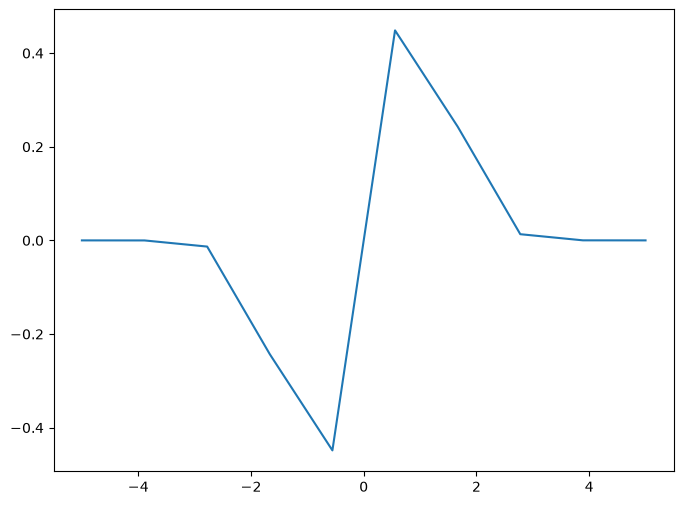

In [9]:
# Generate x values
x = np.linspace(-5, 5, 10)

# Calculate y values using the function f(x) = x * 2^(-x^2)
y = x*(2**(-x**2))

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x, y)

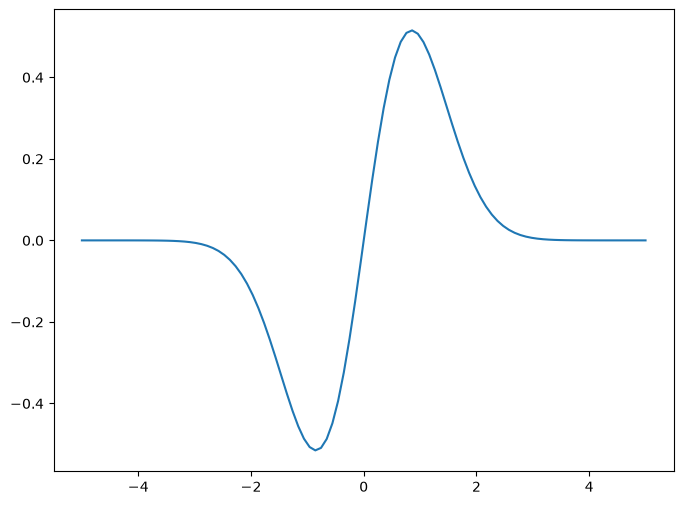

In [10]:
# Generate x values
x1 = np.linspace(-5, 5, 100)

# Calculate y values
y1 = x1*(2**(-x1**2))

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x1, y1)

**Problem 4.** [5 pts] Create a plot of the function `x^4 - 4x^2 + x` for x values in the interval `[-3,3]`. (Use enough grid points to make the plot look reasonably smooth.)

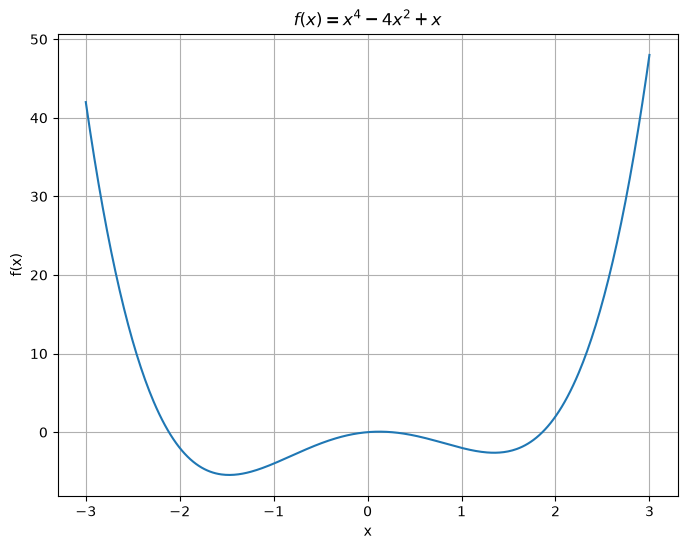

In [11]:
x_grid = np.linspace(-3, 3, 400)
y_grid = x_grid**4 - 4*x_grid**2 + x_grid
plt.figure(figsize=(8, 6))
plt.plot(x_grid, y_grid)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'$f(x) = x^4 - 4x^2 + x$')
plt.grid(True)
plt.show()

# Symbolic Differentiation

The following code demonstrates how to compute derivatives.

In [12]:
import sympy as sym

In [13]:
x, y, z = sym.symbols('x y z') #you only need to declare which symbols are variables once

my_expression = x**3 * y + y**3 + z

derivative1_x = sym.diff(my_expression, x)
print(derivative1_x)

3*x**2*y


Recall this is python notation for $3x^2y$



You can use dictionaries to evaluate the result at specific points.

In [14]:
point = {x: 1, y: 1, z: 1}
value = derivative1_x.subs(point)
print(value)

3


You can also take higher derivatives.

In [15]:
derivative2_x = sym.diff(my_expression, x, 2)
print(derivative2_x)

6*x*y


# Tangent Lines

The following code plots the function $f(x) = x^3$ with the settings:

- the plot is in the interval $(-3,3)$.
- Tangent lines of the function are plotted at the points $x=0$ and $x=2$.

Run this code.

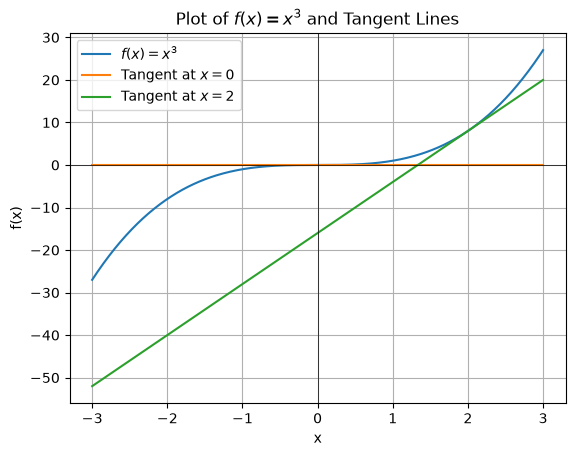

In [16]:
# Define the function f(x) = x^3
def f(x):
    return x**3

# Define the tangent line function
def tangent_line(x, x0):
    slope = 3 * x0**2  # Derivative of f(x) = x^3
    return slope * (x - x0) + f(x0)

# Generate x values
x_values = np.linspace(-3, 3, 400)

# Generate y values for the function f(x) = x^3
y_values = f(x_values)

# Plot the function f(x) = x^3
plt.figure()
plt.plot(x_values, y_values, label='$f(x) = x^3$')

# Plot tangent line at x = 0
x0 = 0
plt.plot(x_values, tangent_line(x_values, x0), label='Tangent at $x=0$')

# Plot tangent line at x = 2
x0 = 2
plt.plot(x_values, tangent_line(x_values, x0), label='Tangent at $x=2$')

# Add labels and legend
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Plot of $f(x) = x^3$ and Tangent Lines')
plt.legend()

# Show plot
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.show()

**Problem 5 [10 points]**

Modify the above code so that you can give it any function symbolically and a point, and it will automatically take the derivative and give you the tangent line ready to plot


In [17]:
def symbolic_tangent(expression, variable, point):
    """Return f(point) + f'(point) * (variable - point)."""
    expression = sym.sympify(expression)
    point = sym.sympify(point)
    slope = sym.diff(expression, variable).subs(variable, point)
    value = expression.subs(variable, point)
    return sym.simplify(value + slope * (variable - point))


def evaluate_on_grid(expression, variable, grid):
    """Evaluate symbolic expressions, including constants, on a NumPy grid."""
    grid = np.asarray(grid, dtype=float)
    function = sym.lambdify(variable, expression, modules='numpy')
    values = np.asarray(function(grid), dtype=float)
    return np.broadcast_to(values, grid.shape)


# Reproduce the supplied cubic example using symbolic differentiation.
cubic = x**3
print("Tangent to x**3 at x=0:", symbolic_tangent(cubic, x, 0))
print("Tangent to x**3 at x=2:", symbolic_tangent(cubic, x, 2))

Tangent to x**3 at x=0: 0


Tangent to x**3 at x=2: 12*x - 16


**Problem 6** [5 pts]

Now with your new code, run it with the function $f(x) = x^2 -1 $ and with the settings:

- the plot is in the interval $(-1,1)$.
- Tangent lines of the function are plotted at the points $x=0$ and $x=1/2$.

Tangent at x=0: -1
Tangent at x=1/2: x - 5/4


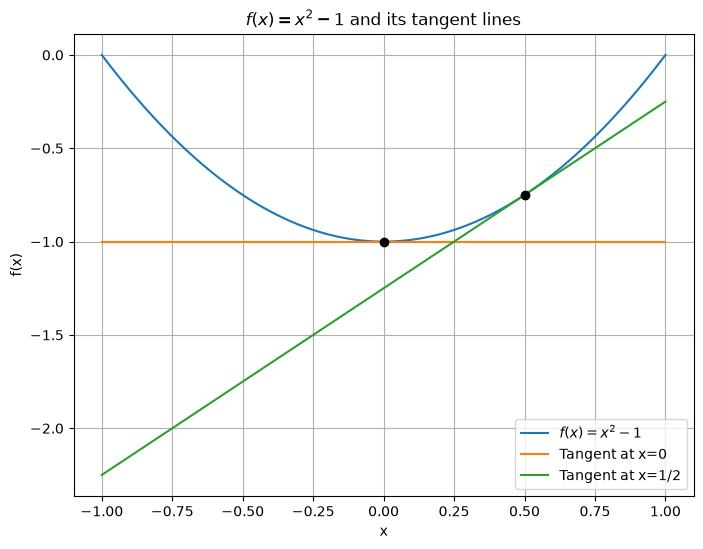

In [18]:
expression = x**2 - 1
x_grid = np.linspace(-1, 1, 400)
plt.figure(figsize=(8, 6))
plt.plot(x_grid, evaluate_on_grid(expression, x, x_grid), label=r'$f(x)=x^2-1$')

for point in [sym.Integer(0), sym.Rational(1, 2)]:
    tangent = symbolic_tangent(expression, x, point)
    print(f"Tangent at x={point}: {tangent}")
    plt.plot(x_grid, evaluate_on_grid(tangent, x, x_grid),
             label=f'Tangent at x={point}')
    plt.scatter(float(point), float(expression.subs(x, point)), color='black', zorder=5)

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'$f(x)=x^2-1$ and its tangent lines')
plt.legend()
plt.grid(True)
plt.show()

We can also plot in 3D - change elev and azim to get different views!

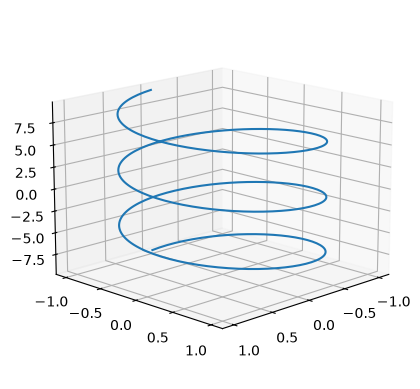

In [19]:
# Create a figure and an axes object with a 3D projection
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

t_values = np.linspace(-3*np.pi, 3*np.pi, 400)
x_val = np.sin(t_values)
y_val = np.cos(t_values)
z_val = t_values

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x_val, y_val, z_val)

# Rotate the plot programmatically - change these values
ax.view_init(elev=15, azim=45)

plt.show()

**Problem 7** [10 pts]

Write code that computes and plots the tangent line to the above curve when $t=\pi$.  Your plot should also include the original function.

Point at t=pi: Matrix([[0, -1, pi]])
Tangent direction at t=pi: Matrix([[-1, 0, 1]])
Tangent line: Matrix([[-s, -1, s + pi]])


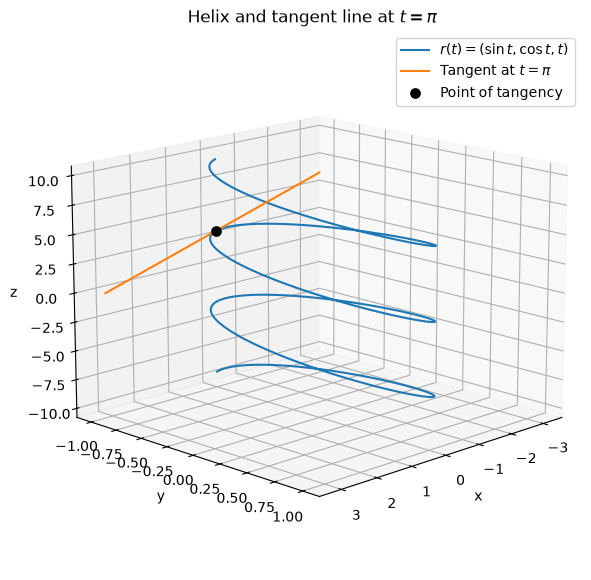

In [20]:
t, s = sym.symbols('t s', real=True)
curve = sym.Matrix([sym.sin(t), sym.cos(t), t])
point = curve.subs(t, sym.pi)
direction = curve.diff(t).subs(t, sym.pi)
tangent = point + s * direction
print("Point at t=pi:", point.T)
print("Tangent direction at t=pi:", direction.T)
print("Tangent line:", tangent.T)

t_grid = np.linspace(-3*np.pi, 3*np.pi, 400)
s_grid = np.linspace(-np.pi, np.pi, 400)
curve_values = [evaluate_on_grid(component, t, t_grid) for component in curve]
tangent_values = [evaluate_on_grid(component, s, s_grid) for component in tangent]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(*curve_values, label=r'$r(t)=(\sin t,\cos t,t)$')
ax.plot(*tangent_values, label=r'Tangent at $t=\pi$', color='tab:orange')
ax.scatter(*[float(component) for component in point], color='black', s=45,
           label='Point of tangency')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(r'Helix and tangent line at $t=\pi$')
ax.view_init(elev=15, azim=45)
ax.legend()
plt.show()

At $t=\pi$, the helix passes through $(0,-1,\pi)$ and has derivative $(-1,0,1)$. Therefore its tangent line is $\mathbf{L}(s)=(0,-1,\pi)+s(-1,0,1)$, or $(-s,-1,\pi+s)$.